In [490]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from cuda_cqed.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

# Hamiltonian

This is post-Bogoliubov

$$
H = \omega_b b^{\dagger} b + \omega_c c^{\dagger} c + 6 g_3 \lambda ( b^{\dagger} c \eta  + b c^{\dagger} \eta^* )  + K_4 b^{\dagger} b^{\dagger} b b + K_6 b^{\dagger} b^{\dagger} b^{\dagger} b b b
$$


No squeezing here, so throwing out the $bb$ type terms in the following

# Heisenberg EoM calcs

In [491]:
from openfermion.ops import BosonOperator
from openfermion.transforms import normal_ordered
from openfermion.utils import commutator

from sympy import symbols
import numpy as np
K4, K6, g3, eta, conj_eta = symbols('K4, K6, g_3, eta, conj_eta', real=True)
wb, wc, λ_bc, λ_bs = symbols('ω_b, ω_c, lambda_bc, lambda_bs', real=True)

H = BosonOperator('0^ 0', wb) + BosonOperator('1^ 1', wc) + 6*g3*λ_bc*(conj_eta*BosonOperator('0^ 1')+eta*BosonOperator('0 1^')) + K4*BosonOperator('0^ 0^ 0 0') + K6*BosonOperator('0^ 0^ 0^ 0 0 0')
print(H)

6.0*eta*g_3*lambda_bc [0 1^] +
ω_b [0^ 0] +
1.0*K4 [0^ 0^ 0 0] +
1.0*K6 [0^ 0^ 0^ 0 0 0] +
6.0*conj_eta*g_3*lambda_bc [0^ 1] +
ω_c [1^ 1]


In [492]:
print('b EoM: ', normal_ordered(1j*commutator(H, BosonOperator('0'))))
print('')
# print('bb EoM: ', normal_ordered(commutator(H, BosonOperator('0 0'))))
print('')
print('bdagb EoM: ', normal_ordered(1j*commutator(H, BosonOperator('0^ 0'))))
print('')
print('c EoM: ', normal_ordered(1j*commutator(H, BosonOperator('1'))))
print('')
# print('cc EoM: ', normal_ordered(commutator(H, BosonOperator('1 1'))))
print('')
print('cdagc EoM: ', normal_ordered(1j*commutator(H, BosonOperator('1^ 1'))))
print('')
# print('bc EoM: ', normal_ordered(commutator(H, BosonOperator('0 1'))))
print('')
print('bdagc EoM: ', normal_ordered(1j*commutator(H, BosonOperator('0^ 1'))))

b EoM:  -1.0*I*ω_b [0] +
-2.0*I*K4 [0^ 0 0] +
-3.0*I*K6 [0^ 0^ 0 0 0] +
-6.0*I*conj_eta*g_3*lambda_bc [1]


bdagb EoM:  6.0*I*eta*g_3*lambda_bc [0 1^] +
-6.0*I*conj_eta*g_3*lambda_bc [0^ 1]

c EoM:  -6.0*I*eta*g_3*lambda_bc [0] +
-1.0*I*ω_c [1]


cdagc EoM:  -6.0*I*eta*g_3*lambda_bc [0 1^] +
6.0*I*conj_eta*g_3*lambda_bc [0^ 1]


bdagc EoM:  -6.0*I*eta*g_3*lambda_bc [0^ 0] +
2.0*I*K4 [0^ 0^ 0 1] +
3.0*I*K6 [0^ 0^ 0^ 0 0 1] +
1.0*I*ω_b - 1.0*I*ω_c [0^ 1] +
6.0*I*eta*g_3*lambda_bc [1^ 1]


# Cumulant equations


$$
\dot{ <b> } = - i \omega_b <b> - 6 i \eta g_3 \lambda <c> - 2i K_4 <b^{\dagger} b > <b>
$$
$$
\dot{<b^{\dagger} b>} = +6 i \eta^* g_3 \lambda <b^{\dagger}c>^* - 6 i \eta g_3 \lambda <b^{\dagger}c>
$$

$$
\dot{ <c> } = - i \omega_c <c> - 6 i \eta^* g_3 \lambda <b>
$$
$$
\dot{<c^{\dagger} c>} = -6 i \eta^* g_3 \lambda <b^{\dagger}c>^* + 6 i \eta g_3 \lambda <b^{\dagger}c>
$$

$$
\dot{ <b^{\dagger} c> } = - 6i \eta^* g_3 \lambda <b^{\dagger} b> + i (\omega_b - \omega_c) <b^{\dagger}c> + 6 \eta^* g_3 \lambda <c^{\dagger} c> + 2i K_4 <b^{\dagger} c> <b^{\dagger} b>
$$


Adding the static loss terms
$$
\dot{ <b> } = - i \omega_b <b> - 6 i \eta g_3 \lambda <c> - 2i K_4 <b^{\dagger} b > <b> - \kappa_b/2 <b>
$$
$$
\dot{<b^{\dagger} b>} = +6 i \eta^* g_3 \lambda <b^{\dagger}c>^* - 6 i \eta g_3 \lambda <b^{\dagger}c>  - \kappa_b <b^{\dagger} b>
$$

$$
\dot{ <c> } = - i \omega_c <c> - 6 i \eta^* g_3 \lambda <b> - \kappa_c/2 <c>
$$
$$
\dot{<c^{\dagger} c>} = -6 i \eta^* g_3 \lambda <b^{\dagger}c>^* + 6 i \eta g_3 \lambda <b^{\dagger}c> - \kappa_c <c^{\dagger} c>
$$

$$
\dot{ <b^{\dagger} c> } = - 6i \eta^* g_3 \lambda <b^{\dagger} b> + i (\omega_b - \omega_c) <b^{\dagger}c> + 6 i \eta^* g_3 \lambda <c^{\dagger} c> + 2i K_4 <b^{\dagger} c> <b^{\dagger} b> - \frac{\kappa_b + \kappa_c}{2} <b^{\dagger} c>
$$


## Fast Res Driving

In [494]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wb', 5.4e9*2*pi)
sim.add_param('wc', 7.3e9*2*pi, is_excitation=True)
sim.add_param('sqrtkb', np.sqrt(0.3e6 * 2 * np.pi))
sim.add_param('sqrtkc', np.sqrt(1.5e6 * 2 * np.pi))
sim.add_param('g3', 10e6*2*np.pi)
sim.add_param('K4', 0.1e6 * 2 * np.pi)
sim.add_param('K6', -0.01e6 * 2 * np.pi)
sim.add_param('lambdaa', 0.1)

sim.add_paramsweep('etaa', 0, 3, 101)
sim.add_paramsweep('wC2', 1.85e9 * 2 * np.pi,  1.95e9 * 2 * np.pi, 101)
sim.add_param('rampC2', 1e-9)
sim.add_param('startC2', 20e-9)
sim.add_param('stopC2', 150e-9)
sim.add_param('phaseC2', 1)

sim.add_param('b_disp', 0.0)
sim.add_paramsweep('c_disp', 1, 10, 10)

C2pulse = sim.make_pulse('wC2', 'etaa', 'phaseC2', 'startC2', 'stopC2', 'rampC2')

sim.add_EOM('pump', C2pulse)
sim.add_EOM('b', '-1j*wb*b - 6j*conjugate(pump)*g3*lambdaa*c - sqrtkb**2/2*b - 2j*K4*bdagb*b - abs(K4)*bdagb*b  - 3j*K6*bdagb**2*b - abs(K6)*bdagb**2*b ', IC_str='b_disp')
sim.add_EOM('bdagb', '6j*pump*g3*lambdaa*conjugate(bdagc) - 6j*conjugate(pump)*g3*lambdaa*bdagc - sqrtkb**2*bdagb', IC_str='abs(b_disp)**2')
sim.add_EOM('c', '-1j*wc*c - 6j*pump*g3*lambdaa*b - sqrtkc**2/2*c', IC_str='c_disp')
sim.add_EOM('cdagc', '- 6j*pump*g3*lambdaa*conjugate(bdagc) + 6j*conjugate(pump)*g3*lambdaa*bdagc - sqrtkc**2*cdagc', IC_str='abs(c_disp)**2')
sim.add_EOM('bdagc', '-6j*pump*g3*lambdaa*bdagb + 1j*(wb-wc)*bdagc + 6j*pump*g3*lambdaa*cdagc + 2j*K4*bdagc*bdagb  + 3j*K6*bdagc*bdagb**2 - (sqrtkb**2/2+sqrtkc**2/2+abs(K4)*bdagb+abs(K6)*bdagb**2)*bdagc')
sim.set_solve_type('decimate')

sim.specify_time(pts_per_cycle=40, num_cycles=1000, d_factor=10)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


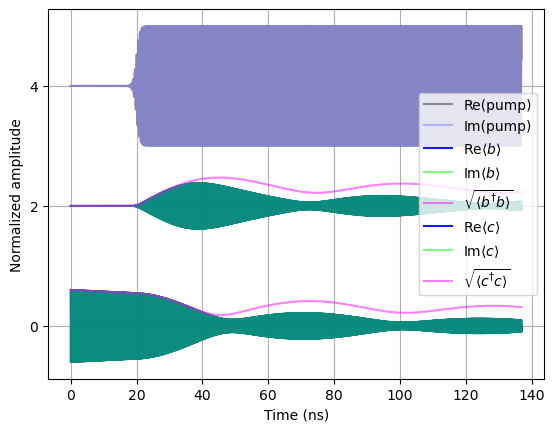

In [495]:
x, t = sim.quick_trace()

scale = 10

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(np.abs(x[0:1,:]))+4,color=(0.5,0.5,0.5,0.9),label='Re(pump)')
plt.plot(t*1e9, x[1,:]/np.max(np.abs(x[0:1,:]))+4,color=(0.5,0.5,1,0.5),label='Im(pump)')
plt.plot(t*1e9, x[2,:]/scale+2,color=(0,0,1,0.9),label=r'Re$\langle b \rangle $')
plt.plot(t*1e9, x[3,:]/scale+2,color=(0,1,0,0.5),label=r'Im$\langle b \rangle $')
plt.plot(t*1e9, np.sqrt(x[4,:])/scale+2,color=(1,0,1,0.5),label=r'$\sqrt{\langle b^{\dagger} b \rangle} $')
plt.plot(t*1e9, x[6,:]/scale+0,color=(0,0,1,0.9),label=r'Re$\langle c \rangle $')
plt.plot(t*1e9, x[7,:]/scale+0,color=(0,1,0,0.5),label=r'Im$\langle c \rangle $')
plt.plot(t*1e9, np.sqrt(x[8,:])/scale+0,color=(1,0,1,0.5),label=r'$\sqrt{\langle c^{\dagger} c \rangle} $')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.yticks([0,2,4])
plt.grid()
plt.show()

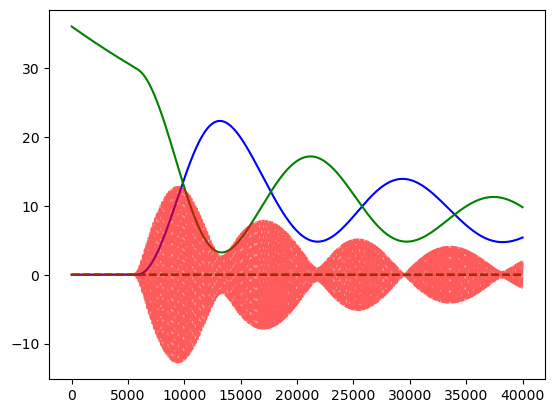

In [496]:
plt.plot(x[4,:],'b-')
plt.plot(x[5,:],'b--')

plt.plot(x[8,:],'g-')
plt.plot(x[9,:],'g--')

plt.plot(x[10,:],'r-', alpha=0.4)
plt.plot(x[11,:],'r--',alpha=0.4)
plt.show()

In [497]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 40000/40000 [01:28<00:00, 449.88it/s]


 
...finished GPU solve!


In [484]:
sqrtkb = sim.param_dict_nosweep['sqrtkb']
sqrtkc = sim.param_dict_nosweep['sqrtkc']

bout_I = I[2,:]
bout_Q = I[3,:]

b_nbar = np.abs(I[4,:])

cout_I = Q[6,:]
cout_Q = Q[7,:]

c_nbar = I[8,:]

In [485]:
np.shape(bout_I)

(101, 101, 10, 100)

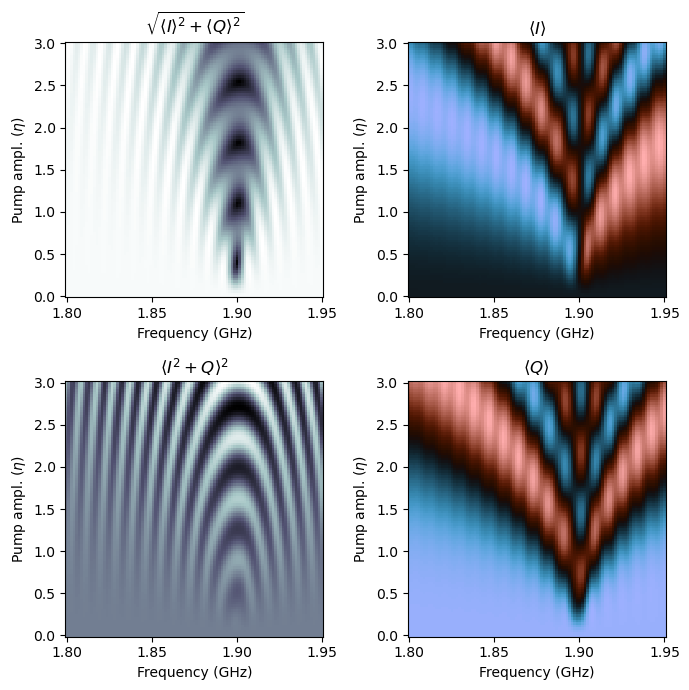

In [489]:
i = 4
b_mag_i = np.abs(bout_I[:,:,i,-1] + 1j*bout_Q[:,:,i,-1])
b_nbar_i = b_nbar[:,:,i,-1]

c_mag_i = np.abs(cout_I[:,:,i,-1] + 1j*cout_Q[:,:,i,-1])
c_nbar_i = c_nbar[:,:,i,-1]

bI_i = bout_I[:,:,i,-1]
bQ_i = bout_Q[:,:,i,-1]

cI_i = cout_I[:,:,i,-1]
cQ_i = cout_Q[:,:,i,-1]

fig, axs = plt.subplots(figsize=(7,7), dpi=100, nrows=2, ncols=2)
axs[0,0].pcolor(sim.paramsweep_dict['wC2']/(2e9*np.pi), sim.paramsweep_dict['etaa'], c_mag_i, cmap='bone')
axs[0,0].set_title(r'$\sqrt{\langle I \rangle^2 + \langle Q \rangle^2}$')
axs[0,0].set_xlabel('Frequency (GHz)')
axs[0,0].set_ylabel(r'Pump ampl. ($\eta$)')

axs[1,0].pcolor(sim.paramsweep_dict['wC2']/(2e9*np.pi), sim.paramsweep_dict['etaa'], c_nbar_i, cmap='bone')
axs[1,0].set_title(r'$\langle I^2 + Q \rangle^2$')
axs[1,0].set_xlabel('Frequency (GHz)')
axs[1,0].set_ylabel(r'Pump ampl. ($\eta$)')

axs[0,1].pcolor(sim.paramsweep_dict['wC2']/(2e9*np.pi), sim.paramsweep_dict['etaa'], cI_i, cmap='berlin')
axs[0,1].set_title(r'$\langle I \rangle$')
axs[0,1].set_xlabel('Frequency (GHz)')
axs[0,1].set_ylabel(r'Pump ampl. ($\eta$)')

axs[1,1].pcolor(sim.paramsweep_dict['wC2']/(2e9*np.pi), sim.paramsweep_dict['etaa'], cQ_i, cmap='berlin')
axs[1,1].set_title(r'$\langle Q \rangle$')
axs[1,1].set_xlabel('Frequency (GHz)')
axs[1,1].set_ylabel(r'Pump ampl. ($\eta$)')
fig.tight_layout()
plt.show()

In [476]:
na = I[3,:]

In [367]:
9.5**2

90.25